In [11]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [ ]:
folder = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_08_09_29_trial_344'
folder = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_09_14_06_trial_0'

In [13]:
result_files = glob.glob(os.path.join(folder, "*results.csv"))
all_results = {}
for f in result_files:
    network = f.split('_')[-2:-1][0]
    all_results[network] = {}
    all_results[network]['results'] = np.loadtxt(f)
    
weight_files = glob.glob(os.path.join(folder, "*ws.pickle"))
for f in weight_files:
    network = f.split('_')[-2:-1][0]
    with open(f, 'rb') as pf:
        all_results[network]['weights'] = pickle.load(pf)

In [14]:
s_acc = np.zeros(len(result_files))
e_acc = np.zeros_like(s_acc)

N = 20

rolling_means = []

for i, results in enumerate(all_results.values()):
    s_acc[i] = np.mean(results['results'][:N])
    e_acc[i] = np.mean(results['results'][-N:])

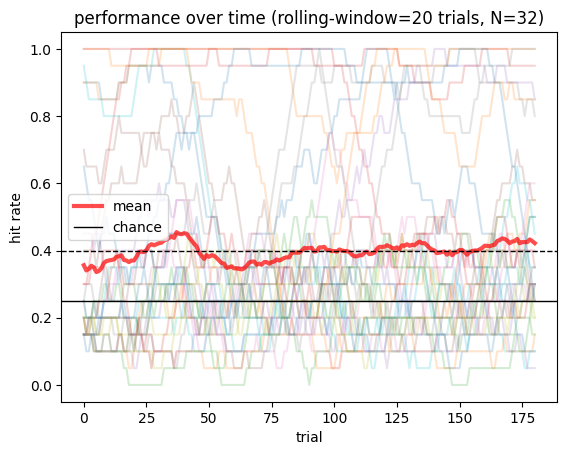

In [15]:
rolling_means = []
for network in sorted(all_results.keys(), key=int):
    window = 20
    weights = np.ones(window) / window

    rolling_mean = np.convolve(all_results[network]['results'], weights, mode='valid')
    rolling_means.append(rolling_mean)
    plt.plot(rolling_mean, linewidth=1.5, alpha=0.2)
    
plt.plot(np.array(rolling_means).mean(axis=0), color='r', alpha=0.7, linewidth=3, label='mean')
plt.axhline(0.25, linestyle='-', color='black', linewidth=1, label='chance')
plt.axhline(0.4, linestyle='--', color='black', linewidth=1)

plt.title(f'performance over time (rolling-window=20 trials, N={len(result_files)})')
plt.legend()
plt.ylabel('hit rate')
plt.xlabel('trial')

plt.show()

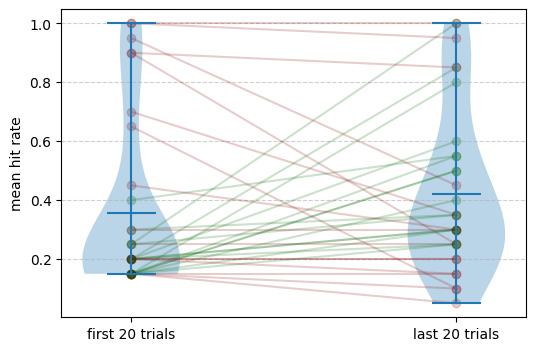

In [16]:
plt.figure(figsize=(6, 4))

for i, (s, e) in enumerate(zip(s_acc, e_acc)):
    color = 'darkgreen' if e > s else 'darkred'
    plt.plot([0, 1], [s, e], marker='o', linestyle='-', alpha=0.2, color=color)
    

plt.violinplot([s_acc, e_acc], 
               positions=[0,1],
               showmeans=True, 
               # showmedians=True,
               showextrema=True, 
               widths=0.3)

plt.xticks([0, 1], [f'first {N} trials', f'last {N} trials'])
plt.ylabel('mean hit rate')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [17]:
print(f"{np.mean(s_acc):.3f}")
print(f"{np.mean(e_acc):.3f}")
print(f"{np.mean(e_acc - s_acc):.3f}")

0.356
0.422
0.066


In [18]:
from scipy.stats import shapiro

diff = e_acc - s_acc
shapiro(diff)


ShapiroResult(statistic=np.float64(0.9420025888616755), pvalue=np.float64(0.08534321139549367))

In [19]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(s_acc, e_acc)
print("t =", t_stat, "p =", p_val)

t = -1.1688215002344935 p = 0.25138528150009326


In [20]:
from scipy.stats import wilcoxon

w, p = wilcoxon(s_acc, e_acc)
print("W =", w, "p =", p)


W = 125.0 p = 0.19936100985393124
